In [ ]:
import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, average_precision_score, PrecisionRecallDisplay, precision_recall_curve
from xgboost import XGBClassifier
import xgboost as xgb

## Load data

In [2]:
df2 = pd.read_csv(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv") #Local
df2.head(20)

,child_age,child_weight,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,malnurished,province_1.0,province_2.0,province_3.0,province_4.0,province_5.0,province_6.0,province_7.0
0,1,-1.085628,0,0,0,1,5,0,1,1,1,0,0,0,0,0,0
1,3,0.420314,0,1,0,1,5,0,1,1,1,0,0,0,0,0,0
2,2,-0.028264,1,0,0,0,2,0,1,0,1,0,0,0,0,0,0
3,1,-0.605008,1,1,0,0,2,0,1,0,1,0,0,0,0,0,0
4,4,1.125224,0,0,0,0,2,0,1,0,1,0,0,0,0,0,0
5,0,-1.374000,0,0,0,0,2,0,1,0,1,0,0,0,0,0,0
6,1,-0.220512,0,0,0,1,5,0,1,0,1,0,0,0,0,0,0
7,1,-0.252553,0,0,0,0,2,0,1,0,1,0,0,0,0,0,0
8,4,1.349513,0,0,0,1,2,0,1,1,1,0,0,0,0,0,0
9,3,0.324190,0,1,0,1,2,0,1,1,1,0,0,0,0,0,0


### Train-test split

In [3]:
X = df2.drop(columns=['malnurished'])
y = df2['malnurished']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state=42)

### SMOTE

In [ ]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print('Before SMOTE: ', Counter(y_train))
print('After SMOTE: ', Counter(y_train_sm))

Before SMOTE:  Counter({0: 2828, 1: 2316})
After SMOTE:  Counter({1: 2828, 0: 2828})


# Extreme Gradient Boosting (XGBoost)

### Simple model

In [7]:
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(X_train_sm, y_train_sm)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [8]:
y_pred = xgb.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.72      0.73       707
           1       0.67      0.71      0.69       579

    accuracy                           0.71      1286
   macro avg       0.71      0.71      0.71      1286
weighted avg       0.72      0.71      0.71      1286



### Average Precision

In [9]:
y_probas = xgb.predict_proba(X_test)[:, 1]
print(f'Average Precision: {average_precision_score(y_test, y_probas)}')

Average Precision: 0.8014529345028426


# Hyperparameter Tuning

In [200]:
# params = {
#     'n_estimators': [50, 100, 150],
#     'max_depth': [3, 5, 7],
#     'learning_rate': [0.01, 0.1, 0.2],
#     'subsample': [0.7, 0.8, 1],
#     'colsample_bytree': [0.7, 0.8, 1]
# }

# xgb_params = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# grid_search = GridSearchCV(
#     estimator = xgb_params ,
#     param_grid=params,
#     scoring='recall',
#     cv=5,
#     verbose=1,
#     n_jobs=-1
# )

# grid_search.fit(X_train, y_train)

In [10]:
params = {
    'n_estimators': [int(x) for x in np.linspace(start=50, stop = 200, num=5)],
    'max_depth': [4, 5, 6, 7],
    # 'min_child_weight': [1, 3, 5],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

xgb_params = XGBClassifier(eval_metric='logloss', random_state=42)

grid_search = GridSearchCV(
    estimator = xgb_params ,
    param_grid=params,
    scoring='recall',
    cv=10,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_sm, y_train_sm)

Fitting 10 folds for each of 540 candidates, totalling 5400 fits


GridSearchCV(cv=10,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constrain...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7, 0.8, 0.9],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [4, 5, 6, 7],
                         'n_estimators': [50, 87, 125, 162, 200],
                         'subsample': [0.7, 0.8, 1]},
             scoring='recall', verbose=1)

In [11]:
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 50, 'subsample': 0.8}
Best Cross-Validation Accuracy: 0.7613324812670726


In [12]:
xgb_tune = grid_search.best_estimator_
y_pred = xgb_tune.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.69      0.74       707
           1       0.67      0.78      0.72       579

    accuracy                           0.73      1286
   macro avg       0.73      0.73      0.73      1286
weighted avg       0.74      0.73      0.73      1286



In [13]:
print(xgb_tune.score(X_train, y_train)) # Train accuracy
print(xgb_tune.score(X_test, y_test)) # Test accuracy

0.7422239502332815
0.7293934681181959


## Average precision

In [14]:
y_probas_tune = xgb_tune.predict_proba(X_test)[:, 1]
print(f'Average Precision: {average_precision_score(y_test, y_probas_tune)}')

Average Precision: 0.8123276349569345


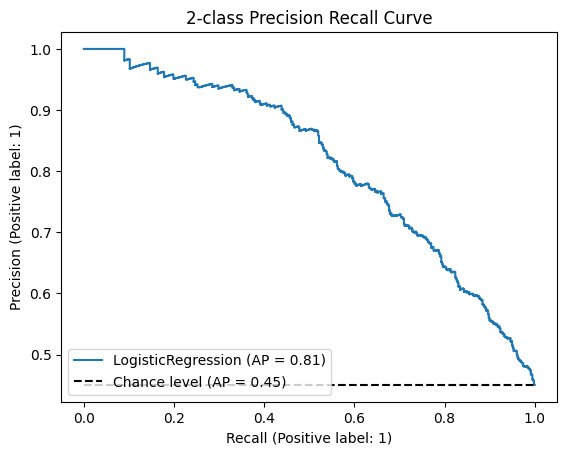

In [15]:
display = PrecisionRecallDisplay.from_estimator(
    xgb_tune,
    X_test,
    y_test, 
    name="LogisticRegression",
    plot_chance_level = True,
)
display.ax_.set_title('2-class Precision Recall Curve')
plt.show()

### Confusion matrix

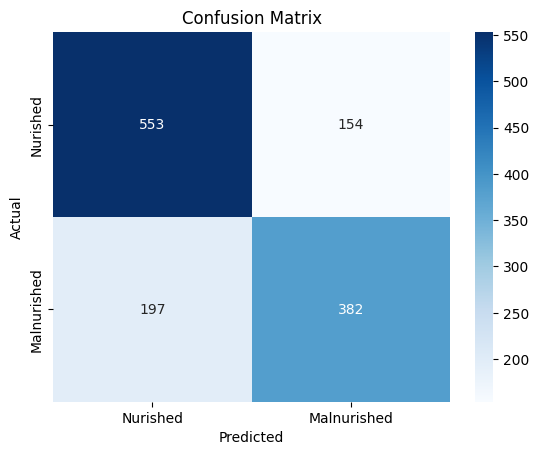

In [207]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Nurished', 'Malnurished'], yticklabels=['Nurished', 'Malnurished'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Feature Importance

In [208]:
# Assuming your model is trained as xgb_model
importances = xgb_tune.feature_importances_
feature_names = X_train.columns

# Create a DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances,
    'Importance (abs)': np.abs(importances)
}).sort_values(by='Importance', ascending=False)

print(importance_df)

                   Feature  Importance  Importance (abs)
0                child_age    0.197357          0.197357
1             child_weight    0.102702          0.102702
5                child_sex    0.059854          0.059854
7         health_insurance    0.058904          0.058904
10            province_2.0    0.055536          0.055536
11            province_3.0    0.051414          0.051414
9             province_1.0    0.050985          0.050985
12            province_4.0    0.050524          0.050524
6         mother_education    0.050342          0.050342
8             wealth_index    0.049379          0.049379
13            province_5.0    0.048803          0.048803
14            province_6.0    0.048649          0.048649
4                     area    0.045207          0.045207
3       fever_last_2_weeks    0.044675          0.044675
2   diarrhoea_last_2_weeks    0.042844          0.042844
15            province_7.0    0.042825          0.042825


In [209]:
# Plot top features (by gain or weight)
xgb.plot_importance(xgb_tune, importance_type='weight', max_num_features=17)
plt.title("Top 10 Feature Importances (XGBoost - Weight)")
plt.tight_layout()
plt.show()

AttributeError: 'XGBClassifier' object has no attribute 'plot_importance'

## Additional

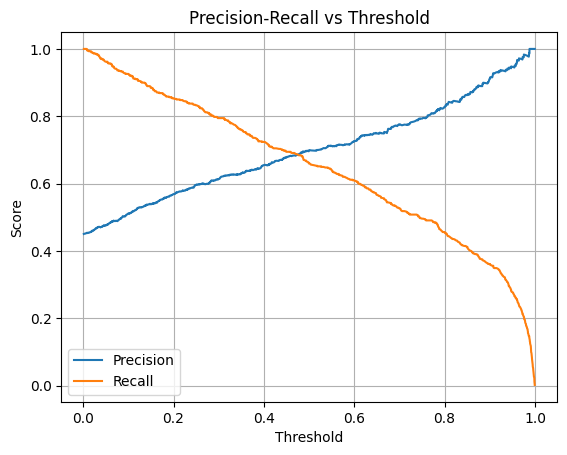

In [ ]:
y_probas = xgb_tune.predict_proba(X_test)[:, 1]       #Probabilities for class 1
precision, recall, thresholds = precision_recall_curve(y_test, y_probas)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.grid()
plt.legend()
plt.show()

In [ ]:
# Apply custom threshold
y_probas_custom = (y_probas >= 0.40).astype(int)
print(f'Classification Report: \n{classification_report(y_test, y_probas_custom)}\n')

Classification Report: 
              precision    recall  f1-score   support

           0       0.75      0.69      0.72       707
           1       0.66      0.72      0.69       579

    accuracy                           0.70      1286
   macro avg       0.70      0.71      0.70      1286
weighted avg       0.71      0.70      0.71      1286


